### DECISION TREE CLASSIFIER MODELING

The following **Decision Tree Classifier models** are prepared:

_Model D1_     
A simple model is first built. The class imbalance is then addressed by using the parameter class_weight. The hyperparameters are optimized and then the best threshold is used to maximize _recall_.

_Model D2_   
Feature selection uses Random Forest Classifier to improve the model.

_Model D3_   
Feature selection uses SelectKBest to improve the model.

For each model, the following **metrics** are determined:    
_AUC_    
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_    
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance and particularly to address overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import graphviz
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [3]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [7]:
# Define numeric_cols
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


In [8]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [9]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [10]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


**Build a simple Decision Tree Classifier model**    
A simple Decision Tree Classifier model is built and called **Model D1**.

In [11]:
# Preprocessing to prepare categorical features encoding, numerical features are not scaled
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[
                ['Monthly','Quarterly','Yearly'],         # contract_type
                ['Unsatisfied','Neutral','Satisfied']     # survey_response
            ],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols),
        ('nom', OneHotEncoder(
            drop=None,
            handle_unknown='ignore'
        ), nominal_cols),
    ],
    remainder='passthrough'
)

In [12]:
# Build pipeline for simple model
dtree_pipe_simple = Pipeline([
    ('preprocessor', preprocessor),
    ('dtree', DecisionTreeClassifier(random_state=42))
])
dtree_pipe_simple.fit(X_train, y_train)
dtree_pipe_simple

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('dtree', DecisionTreeClassifier(random_state=42))])

**Overfit model**    
The simple Decision Tree Classifier model is overfit (100% train accuracy is an indication of overfitting). This is addressed by using the parameter class_weight='balanced' to rectify the class imbalance in the dataset and by optimizing model parameters which includes pruning the overfit tree.

In [13]:
# Define the Model D1 threshold (default)
threshold_D1 = 0.5

In [14]:
# Accuracy of model on train and test data
dtree_pipe_simple_acc_train = dtree_pipe_simple.score(X_train, y_train)
dtree_pipe_simple_acc_test = dtree_pipe_simple.score(X_test, y_test)#

print(f'The train accuracy of the model is {dtree_pipe_simple_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {dtree_pipe_simple_acc_test*100:.2f}%')

The train accuracy of the model is 100.00%
The test accuracy of the model is 84.32%


In [15]:
# Build pipeline for the improved model
dtree_pipe1 = Pipeline([
    ('preprocessor', preprocessor),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
dtree_pipe1.fit(X_train, y_train)
dtree_pipe1

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [16]:
# Define the hyperparameter grid to be fed to GridSearchCV
param_grid_dtree = {
    'dtree__criterion': ['gini', 'entropy'],
    'dtree__max_depth': [5, 6, 7, None],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
    'dtree__min_samples_leaf': [2, 5, 10]
}

In [17]:
# Run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dtree = GridSearchCV(estimator=dtree_pipe1,
                              param_grid=param_grid_dtree,
                              scoring='f1',
                              cv=cv,
                              n_jobs=-1)
grid_dtree.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ord',
                                                                         OrdinalEncoder(categories=[['Monthly',
                                                                                                     'Quarterly',
                                                                                                     'Yearly'],
                                                                                                    ['Unsatisfied',
                                                                                                     'Neutral',
                                                                                                     'Satisfied']],
                                                                                        handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['contract_type',
                                                                          'su...
                                                                          'discount_applied',
                                                                          'price_increase_last_3m',
                                                                          'complaint_type'])])),
                                       ('dtree',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
                         'dtree__criterion': ['gini', 'entropy'],
                         'dtree__max_depth': [5, 6, 7, None],
                         'dtree__min_samples_leaf': [2, 5, 10],
                         'dtree__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [18]:
# Verify the best parameters

print(f'Best parameters: {grid_dtree.best_params_}')
print(f'Best score: {grid_dtree.best_score_:.4f}')

Best parameters: {'dtree__ccp_alpha': 0.005, 'dtree__criterion': 'entropy', 'dtree__max_depth': 5, 'dtree__min_samples_leaf': 2, 'dtree__min_samples_split': 2}
Best score: 0.3794


In [19]:
# Access the optimized pipeline model
dtree_pipe1_opt = grid_dtree.best_estimator_
dtree_pipe1_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('dtree',
                 DecisionTreeClassifier(ccp_alpha=0.005,
                                        class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=2, random_state=42))])

In [20]:
# Accuracy on train and test data
dtree_pipe1_opt_acc_train = dtree_pipe1_opt.score(X_train, y_train)
dtree_pipe1_opt_acc_test = dtree_pipe1_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {dtree_pipe1_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {dtree_pipe1_opt_acc_test*100:.2f}%')

The train accuracy of the model is 74.52%
The test accuracy of the model is 74.81%


In [21]:
# Confirm the depth
depth_D1 = dtree_pipe1_opt.named_steps['dtree'].get_depth()

print(f'The depth is {depth_D1}')

The depth is 4


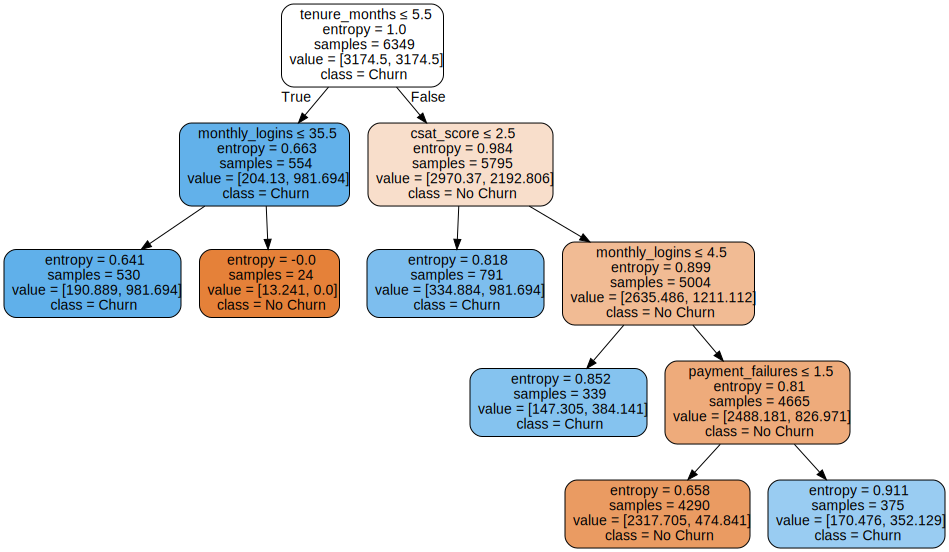

In [22]:
# Visualize the model
feature_names = dtree_pipe1_opt.named_steps['preprocessor'].get_feature_names_out()
clean_names = [i.split('__')[-1] for i in feature_names]

dot_data = export_graphviz(dtree_pipe1_opt.named_steps['dtree'],
                           out_file=None,
                           feature_names=clean_names,
                           class_names=['No Churn','Churn'],
                           filled=True,
                           rounded=True,
                           special_characters=True
)
graph=graphviz.Source(dot_data)
graph

In [23]:
# Generate classification report D1
y_pred_D1 = dtree_pipe1_opt.predict(X_test)

print(classification_report(y_test, y_pred_D1))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.92      0.41       149

    accuracy                           0.75      1588
   macro avg       0.62      0.82      0.62      1588
weighted avg       0.92      0.75      0.80      1588



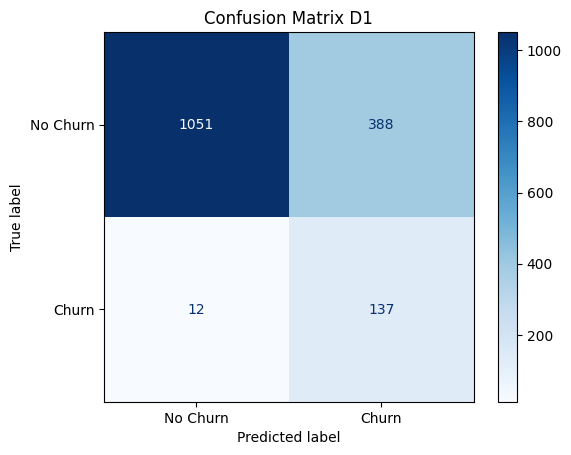

In [24]:
# Display confusion matrix D1
conf_matrix_D1 = confusion_matrix(y_test, y_pred_D1)
disp_D1 = ConfusionMatrixDisplay(conf_matrix_D1, display_labels=['No Churn','Churn'])
disp_D1.plot(cmap='Blues')
plt.title('Confusion Matrix D1')
plt.show()

In [25]:
# Values for false positive (fp_D1), false negative (fn_D1), true positive (tp_D1) and true negative (tn_D1)
fp_D1 = conf_matrix_D1[0][1]
fn_D1 = conf_matrix_D1[1][0]
tp_D1 = conf_matrix_D1[1][1]
tn_D1 = conf_matrix_D1[0][0]

print(f' fp_D1: {fp_D1} \n fn_D1: {fn_D1} \n tp_D1: {tp_D1} \n tn_D1: {tn_D1}')

 fp_D1: 388 
 fn_D1: 12 
 tp_D1: 137 
 tn_D1: 1051


In [26]:
# Calculations for accuracy, precision, recall
accuracy_D1 = (tp_D1 + tn_D1)/len(y_test)
precision_D1 = tp_D1/(tp_D1 + fp_D1)
recall_D1 = tp_D1/(tp_D1 + fn_D1)

print(f'Accuracy: {accuracy_D1:.2f}')
print(f'Precision: {precision_D1:.2f}')
print(f'Recall: {recall_D1:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.26
Recall: 0.92
---------------


In [27]:
# Calculate F2 score
beta = 2
F2_score_D1 = (1 + beta**2) * (precision_D1 * recall_D1) / (beta**2 * precision_D1 + recall_D1)

print(f'The F2 score is {F2_score_D1:.4f}')

The F2 score is 0.6111


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [28]:
# Profit/loss analysis
L=500
C=40
Profit_Loss_D1 = tp_D1*(L - C) - fp_D1*C - fn_D1*L

print(f'The profit or loss is ${Profit_Loss_D1}')

The profit or loss is $41500


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

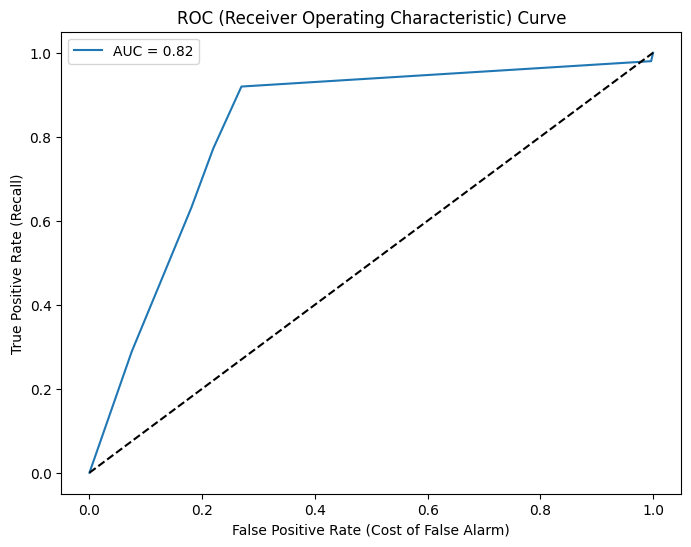

In [29]:
# Plot the ROC Curve
y_probs_D1 = dtree_pipe1_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_D1)
auc_D1 = round(roc_auc_score(y_test, y_probs_D1), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_D1):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [30]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_D1 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_D1 :.4f}')

The optimal threshold is 0.6738


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [31]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_D1)
avg_precision = average_precision_score(y_test, y_probs_D1)

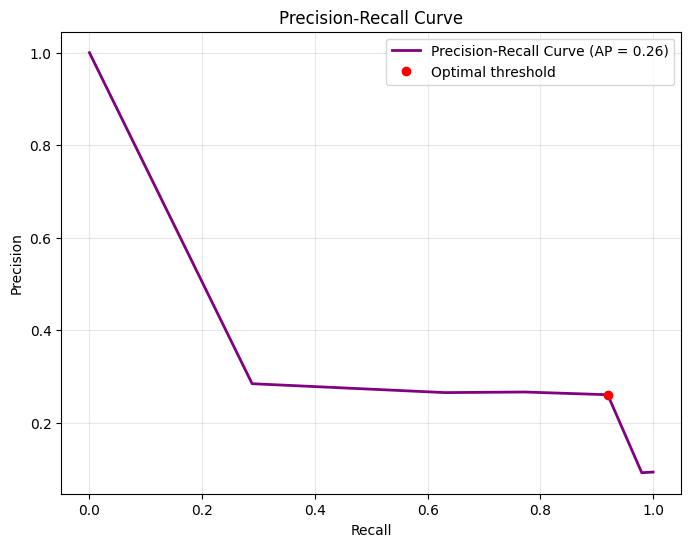

In [32]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_D1))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [33]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_D1 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=0.98
Threshold=0.10 | Precision=0.09 | Recall=0.98
Threshold=0.15 | Precision=0.09 | Recall=0.98
Threshold=0.20 | Precision=0.26 | Recall=0.92
Threshold=0.25 | Precision=0.26 | Recall=0.92
Threshold=0.30 | Precision=0.26 | Recall=0.92
Threshold=0.35 | Precision=0.26 | Recall=0.92
Threshold=0.40 | Precision=0.26 | Recall=0.92
Threshold=0.45 | Precision=0.26 | Recall=0.92
Threshold=0.50 | Precision=0.26 | Recall=0.92
Threshold=0.55 | Precision=0.26 | Recall=0.92
Threshold=0.60 | Precision=0.26 | Recall=0.92
Threshold=0.65 | Precision=0.26 | Recall=0.92
Threshold=0.70 | Precision=0.27 | Recall=0.77
Threshold=0.75 | Precision=0.28 | Recall=0.29


In [34]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_D1 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.2


In [35]:
# Define Model D1 threshold
threshold_D1 = best_threshold

In [36]:
# Use the threshold that maximizes profit
y_pred_D1 = (y_probs_D1 >= best_threshold).astype(int)

The **threshold that maximizes profit** and the **optimal threshold** from the ROC Curve produce the same metrics     

As shown in the table of precision-recall at different thresholds and the following classification report D2, the threshold that maximizes profit and the optimal threshold from the ROC Curve produce the same metrics.  

In [37]:
# Generate classification report

print(classification_report(y_test, y_pred_D1))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.92      0.41       149

    accuracy                           0.75      1588
   macro avg       0.62      0.82      0.62      1588
weighted avg       0.92      0.75      0.80      1588



**Feature Importance Model D1**     
**tenure_months** is the strongest predictor of churn, followed closely by **csat_score** and **monthly_logins** metrics. This suggests that churn risk is highest among newer, less engaged, and less satisfied customers. Operational factors such as **payment_failures** and **avg_resolution_time** also contribute meaningfully to churn behavior.


In [38]:
# Extract the trained tree
dt_model = dtree_pipe1.named_steps['dtree']

In [39]:
# Get feature names after preprocessing
preprocessor = dtree_pipe1.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [40]:
# Match importance to names
importances = dt_model.feature_importances_

D1_feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

D1_feature_importance_df.head(10)

,feature,importance
35,remainder__tenure_months,0.132095
46,remainder__csat_score,0.122937
36,remainder__monthly_logins,0.117773
43,remainder__payment_failures,0.078637
45,remainder__avg_resolution_time,0.050843
38,remainder__avg_session_time,0.050361
40,remainder__usage_growth_rate,0.042743
34,remainder__age,0.041126
49,remainder__marketing_click_rate,0.040918
52,remainder__tenure_fee_interaction,0.040202


In [42]:
# Clean feature names
D1_feature_importance_df['feature'] = (
    D1_feature_importance_df['feature']
    .str.replace('nom__','')
    .str.replace('ord__','')
    .str.replace('remainder__','')
)

D1_feature_importance_df.head(20)

,feature,importance
35,tenure_months,0.132095
46,csat_score,0.122937
36,monthly_logins,0.117773
43,payment_failures,0.078637
45,avg_resolution_time,0.050843
38,avg_session_time,0.050361
40,usage_growth_rate,0.042743
34,age,0.041126
49,marketing_click_rate,0.040918
52,tenure_fee_interaction,0.040202


In [43]:
# Reset index
D1_feature_importance_df = D1_feature_importance_df.reset_index(drop=True)
D1_feature_importance_df.index = D1_feature_importance.index + 1
D1_feature_importance_df.index.name = "Rank"

D1_feature_importance_df.head(10)

NameError: name 'D1_feature_importance' is not defined

In [44]:
# Select the first twenty features for plotting
D1_feature_importance_df = D1_feature_importance_df.iloc[:20]

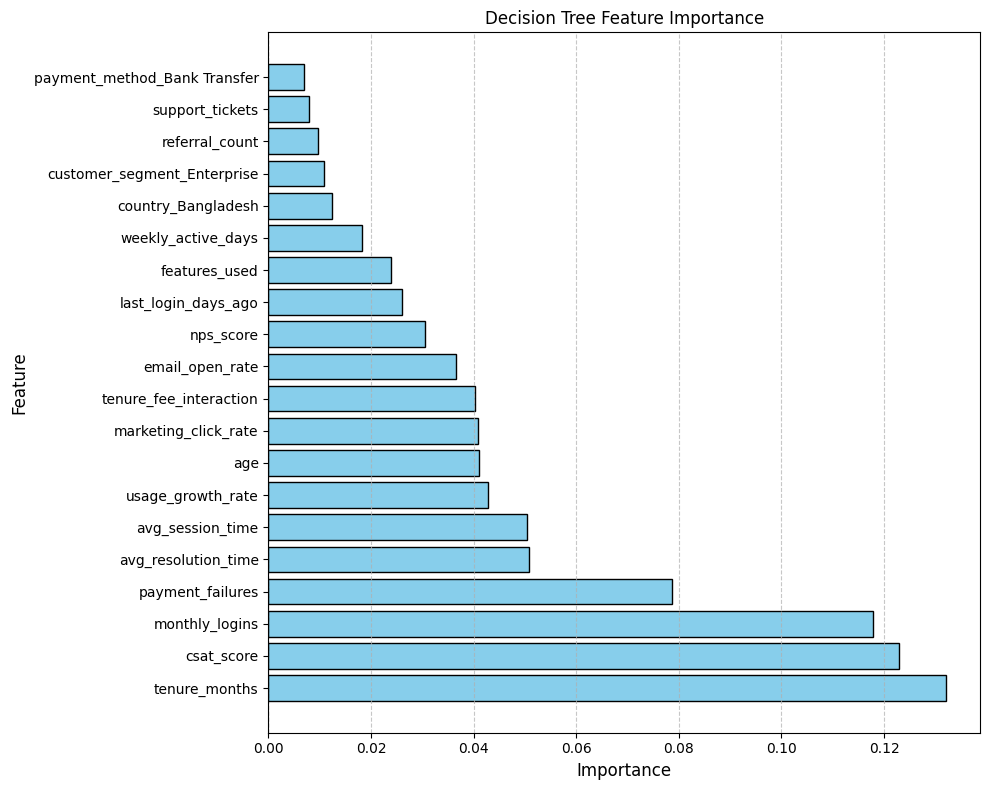

In [45]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['skyblue']
plt.barh(D1_feature_importance_df['feature'], D1_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model D2**    
**Feature selection** using Random Forest Classifier to select the best number of top features.

In [46]:
# Obtain the best number of features based on maximum AUC
auc=[]
features = np.arange(30, 39, 3)
for i in features:
  # Set up selector
  selector = SelectFromModel(RandomForestClassifier(random_state=42), max_features=i,
        threshold=-float("inf"))   # ensures exactly the number of features
  # Build the pipeline
  dtree_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('feature_selection', selector),
      ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
  ])
  dtree_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'dtree__criterion': ['gini', 'entropy'],
      'dtree__max_depth': [5, 6, 7, None],
      'dtree__min_samples_split': [2, 5, 10],
      'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
      'dtree__min_samples_leaf': [2, 5, 10]
  }
  # Run HalvingRandomSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_dtree = HalvingRandomSearchCV(dtree_pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
  grid_dtree.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_dtree_opt = grid_dtree.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_dtree_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 30 | AUC = 0.8391
Number of Features = 33 | AUC = 0.8206
Number of Features = 36 | AUC = 0.8207


In [47]:
# Extract the best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 30.


In [48]:
# Build the pipeline using the best number of features
dtree_pipe_D2 = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(RandomForestClassifier(random_state=42), max_features=best_features,
        threshold=-float("inf"))),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
dtree_pipe_D2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(30), threshold=-inf)),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [49]:
# Define the hyperparameter grid to be fed to GridSearchCV
param_grid_D2 = {
    'dtree__criterion': ['gini', 'entropy'],
    'dtree__max_depth': [5, 6, 7, None],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
    'dtree__min_samples_leaf': [2, 5, 10]
}

In [50]:
# Run HalvingRandomSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dtree_D2 = GridSearchCV(estimator=dtree_pipe_D2,
                              param_grid=param_grid_D2,
                              scoring='f1',
                              cv=cv,
                              n_jobs=-1)
grid_dtree_D2.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ord',
                                                                         OrdinalEncoder(categories=[['Monthly',
                                                                                                     'Quarterly',
                                                                                                     'Yearly'],
                                                                                                    ['Unsatisfied',
                                                                                                     'Neutral',
                                                                                                     'Satisfied']],
                                                                                        handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['contract_type',
                                                                          'su...
                                        SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                                        max_features=np.int64(30),
                                                        threshold=-inf)),
                                       ('dtree',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
                         'dtree__criterion': ['gini', 'entropy'],
                         'dtree__max_depth': [5, 6, 7, None],
                         'dtree__min_samples_leaf': [2, 5, 10],
                         'dtree__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [51]:
# Verify the best parameters

print(f'Best parameters: {grid_dtree_D2.best_params_}')
print(f'Best score: {grid_dtree_D2.best_score_:.4f}')

Best parameters: {'dtree__ccp_alpha': 0.005, 'dtree__criterion': 'entropy', 'dtree__max_depth': 5, 'dtree__min_samples_leaf': 2, 'dtree__min_samples_split': 2}
Best score: 0.3794


In [52]:
# Access the optimized pipeline model
grid_dtree_D2_opt = grid_dtree_D2.best_estimator_
grid_dtree_D2_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country',...
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(30), threshold=-inf)),
                ('dtree',
                 DecisionTreeClassifier(ccp_alpha=0.005,
                                        class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=2, random_state=42))])

In [53]:
# Accuracy on train and test data
grid_dtree_D2_opt_acc_train = grid_dtree_D2_opt.score(X_train, y_train)
grid_dtree_D2_opt_acc_test = grid_dtree_D2_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_dtree_D2_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_dtree_D2_opt_acc_test*100:.2f}%')

The train accuracy of the model is 74.52%
The test accuracy of the model is 74.81%


In [54]:
# Generate classification report
y_pred_D2 = grid_dtree_D2_opt.predict(X_test)

print(classification_report(y_test, y_pred_D2))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.92      0.41       149

    accuracy                           0.75      1588
   macro avg       0.62      0.82      0.62      1588
weighted avg       0.92      0.75      0.80      1588



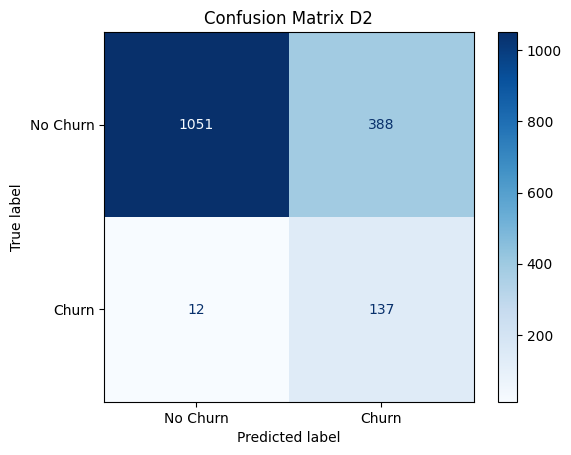

In [55]:
# Display confusion matrix
conf_matrix_D2 = confusion_matrix(y_test, y_pred_D2)
disp_D2 = ConfusionMatrixDisplay(conf_matrix_D2, display_labels=['No Churn','Churn'])
disp_D2.plot(cmap='Blues')
plt.title('Confusion Matrix D2')
plt.show()

In [56]:
# Values for false positive (fp_D2), false negative (fn_D2), true positive (tp_D2) and true negative (tn_D2)
fp_D2 = conf_matrix_D2[0][1]
fn_D2 = conf_matrix_D2[1][0]
tp_D2 = conf_matrix_D2[1][1]
tn_D2 = conf_matrix_D2[0][0]

print(f' fp_D2: {fp_D2} \n fn_D2: {fn_D2} \n tp_D2: {tp_D2} \n tn_D2: {tn_D2}')

 fp_D2: 388 
 fn_D2: 12 
 tp_D2: 137 
 tn_D2: 1051


In [57]:
# Calculations for accuracy, precision, recall
accuracy_D2 = (tp_D2 + tn_D2)/len(y_test)
precision_D2 = tp_D2/(tp_D2 + fp_D2)
recall_D2 = tp_D2/(tp_D2 + fn_D2)

print(f'Accuracy: {accuracy_D2:.2f}')
print(f'Precision: {precision_D2:.2f}')
print(f'Recall: {recall_D2:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.26
Recall: 0.92
---------------


In [58]:
# Calculate F2 score
beta = 2
F2_score_D2 = (1 + beta**2) * (precision_D2 * recall_D2) / (beta**2 * precision_D2 + recall_D2)

print(f'The F2 score is {F2_score_D2:.4f}')

The F2 score is 0.6111


In [59]:
# Profit/loss analysis
Profit_Loss_D2 = tp_D2*(L - C) - fp_D2*C - fn_D2*L

print(f'The profit or loss is ${Profit_Loss_D2}')

The profit or loss is $41500


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

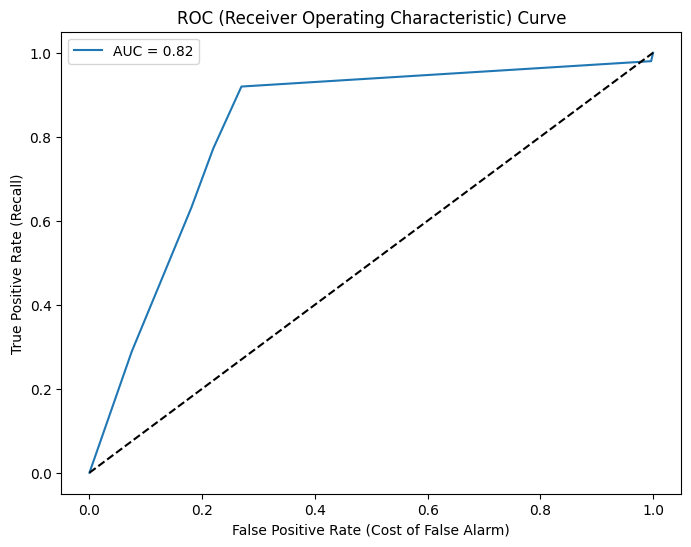

In [60]:
# Plot the ROC Curve
y_probs_D2 = grid_dtree_D2_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_D2)
auc_D2 = round(roc_auc_score(y_test, y_probs_D2), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_D2):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [61]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_D2 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_D2 :.4f}')

The optimal threshold is 0.6738


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [62]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_D2)
avg_precision = average_precision_score(y_test, y_probs_D2)

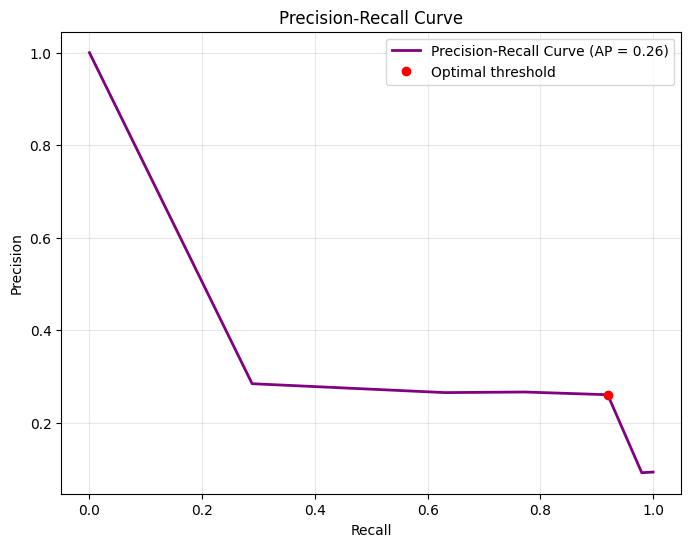

In [63]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_D2))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [64]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_D2 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=0.98
Threshold=0.10 | Precision=0.09 | Recall=0.98
Threshold=0.15 | Precision=0.09 | Recall=0.98
Threshold=0.20 | Precision=0.26 | Recall=0.92
Threshold=0.25 | Precision=0.26 | Recall=0.92
Threshold=0.30 | Precision=0.26 | Recall=0.92
Threshold=0.35 | Precision=0.26 | Recall=0.92
Threshold=0.40 | Precision=0.26 | Recall=0.92
Threshold=0.45 | Precision=0.26 | Recall=0.92
Threshold=0.50 | Precision=0.26 | Recall=0.92
Threshold=0.55 | Precision=0.26 | Recall=0.92
Threshold=0.60 | Precision=0.26 | Recall=0.92
Threshold=0.65 | Precision=0.26 | Recall=0.92
Threshold=0.70 | Precision=0.27 | Recall=0.77
Threshold=0.75 | Precision=0.28 | Recall=0.29


In [65]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_D2 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.2


In [66]:
# Define Model D2 threshold
theshold_D2 = best_threshold

In [67]:
# Use the threshold that maximizes profit
y_pred_D2 = (y_probs_D2 >= best_threshold).astype(int)

In [68]:
# Generate classification report

print(classification_report(y_test, y_pred_D2))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.92      0.41       149

    accuracy                           0.75      1588
   macro avg       0.62      0.82      0.62      1588
weighted avg       0.92      0.75      0.80      1588



As shown in the classification report, the **metrics are the same** at the best threshold.

**Feature importance Model D2**     
**tenure_months** is the strongest predictor of churn, followed closely by **csat_score** and **monthly_logins** metrics. This suggests that churn risk is highest among newer, less engaged, and less satisfied customers. Operational factors such as **payment_failures** and **avg_resolution_time** also contribute meaningfully to churn behavior.

In [69]:
# Retrieve selected features
mask = grid_dtree_D2_opt.named_steps["feature_selection"].get_support()
feature_names = grid_dtree_D2_opt.named_steps["preprocessor"].get_feature_names_out()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names

print(f'There are {len(selected_features)} selected features.')

There are 30 selected features.


In [70]:
# Match importance to feature names
tree_model = grid_dtree_D2_opt.named_steps["dtree"]
importances = tree_model.feature_importances_

D2_feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Reset index
D2_feature_importance_df = D2_feature_importance_df.reset_index(drop=True)
D2_feature_importance_df.index = D2_feature_importance_df.index + 1
D2_feature_importance_df.index.name = "Rank"

D2_feature_importance_df.head(10)

,feature,importance
Rank,,
1,csat_score,0.310217
2,tenure_months,0.276344
3,payment_failures,0.212916
4,monthly_logins,0.200523
5,gender_Female,0.000000
6,country_Germany,0.000000
7,customer_segment_SME,0.000000
8,customer_segment_Individual,0.000000
9,signup_channel_Mobile,0.000000


In [71]:
# Select the first twenty features for plotting
D2_feature_importance_df = D2_feature_importance_df.iloc[:20]

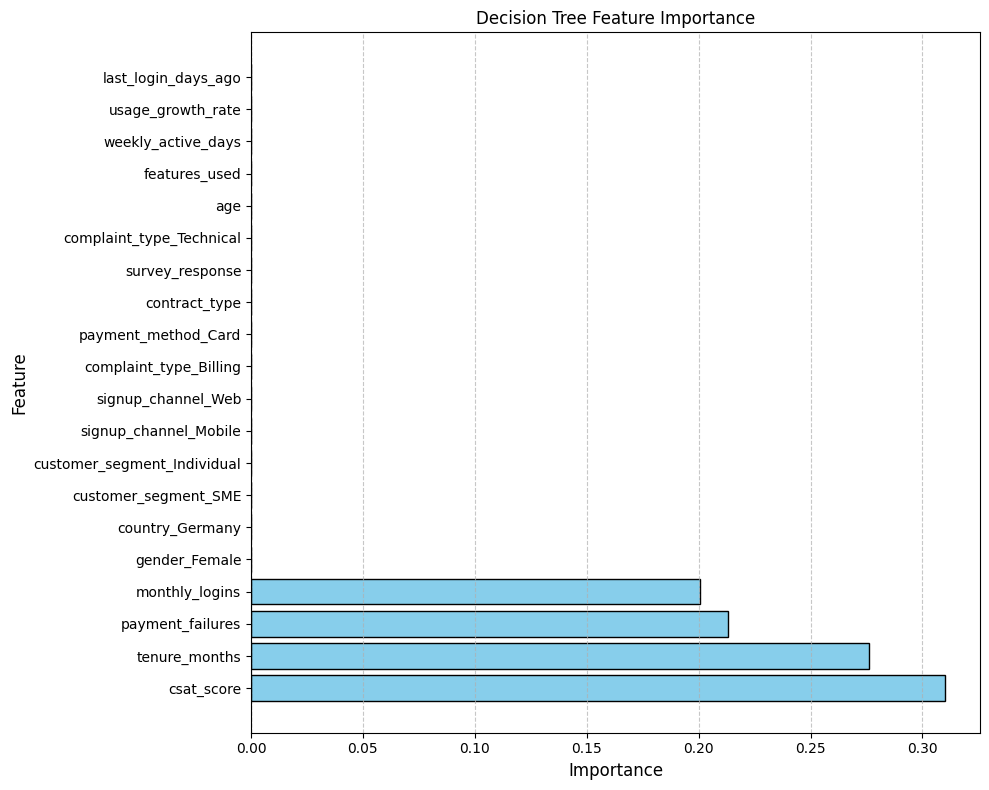

In [72]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['skyblue']
plt.barh(D2_feature_importance_df['feature'], D2_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model D3**    
**Feature selection** uses SelectKBest.

In [73]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(20, 29, 3)
for i in features:
  # Set up selector
  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build the pipeline
  dtree_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('feature_selection', selector),
      ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
  ])
  dtree_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'dtree__criterion': ['gini', 'entropy'],
      'dtree__max_depth': [5, 6, 7, None],
      'dtree__min_samples_split': [2, 5, 10],
      'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
      'dtree__min_samples_leaf': [2, 5, 10]
  }
  # Run RandomizedSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_dtree = HalvingRandomSearchCV(dtree_pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
  grid_dtree.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_dtree_opt = grid_dtree.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_dtree_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Number of Features = 20 | AUC = 0.8120
Number of Features = 23 | AUC = 0.8391
Number of Features = 26 | AUC = 0.8391


In [74]:
# Extract the best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 23.


In [75]:
# Set up selector using the best number of features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [76]:
# Build the pipeline
dtree_pipe_D3 = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', selector),
    ('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
dtree_pipe_D3.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectKBest(k=np.int64(23),
                             score_func=<function mutual_info_classif at 0x7f41ce60b4c0>)),
                ('dtree',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [77]:
# Define the hyperparameter grid to be fed to GridSearchCV
param_grid_D3 = {
    'dtree__criterion': ['gini', 'entropy'],
    'dtree__max_depth': [5, 6, 7, None],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__ccp_alpha': [0.0, 0.001, 0.002, 0.005, 0.01],
    'dtree__min_samples_leaf': [2, 5, 10]
}

In [78]:
# Run HalvingRandomSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dtree_D3 = HalvingRandomSearchCV(dtree_pipe_D3, param_grid_D3, cv=cv, scoring='f1', n_jobs=-1)
grid_dtree_D3.fit(X_train, y_train)

HalvingRandomSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                      estimator=Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('ord',
                                                                                  OrdinalEncoder(categories=[['Monthly',
                                                                                                              'Quarterly',
                                                                                                              'Yearly'],
                                                                                                             ['Unsatisfied',
                                                                                                              'Neutral',
                                                                                                              'Satisfied']],
                                                                                                 handle_unknown='use_encoded_value',
                                                                                                 unknown_value=-1),
                                                                                  ['contract_...
                                                             score_func=<function mutual_info_classif at 0x7f41ce60b4c0>)),
                                                ('dtree',
                                                 DecisionTreeClassifier(class_weight='balanced',
                                                                        random_state=42))]),
                      n_jobs=-1,
                      param_distributions={'dtree__ccp_alpha': [0.0, 0.001,
                                                                0.002, 0.005,
                                                                0.01],
                                           'dtree__criterion': ['gini',
                                                                'entropy'],
                                           'dtree__max_depth': [5, 6, 7, None],
                                           'dtree__min_samples_leaf': [2, 5,
                                                                       10],
                                           'dtree__min_samples_split': [2, 5,
                                                                        10]},
                      scoring='f1')

In [79]:
# Verify the best parameters

print(f'Best parameters: {grid_dtree_D3.best_params_}')
print(f'Best score: {grid_dtree_D3.best_score_:.4f}')

Best parameters: {'dtree__min_samples_split': 2, 'dtree__min_samples_leaf': 5, 'dtree__max_depth': None, 'dtree__criterion': 'gini', 'dtree__ccp_alpha': 0.01}
Best score: 0.3744


In [80]:
# Access the optimized model
grid_dtree_D3_opt = grid_dtree_D3.best_estimator_
grid_dtree_D3_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment',
                                                   'signup_channel',
                                                   'payment_method',
                                                   'discount_applied',
                                                   'price_increase_last_3m',
                                                   'complaint_type'])])),
                ('feature_selection',
                 SelectKBest(k=np.int64(23),
                             score_func=<function mutual_info_classif at 0x7f41ce60b4c0>)),
                ('dtree',
                 DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                                        min_samples_leaf=5, random_state=42))])

In [81]:
# Accuracy on train and test data
grid_dtree_D3_opt_acc_train = grid_dtree_D3_opt.score(X_train, y_train)
grid_dtree_D3_opt_acc_test = grid_dtree_D3_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_dtree_D3_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_dtree_D3_opt_acc_test*100:.2f}%')

The train accuracy of the model is 74.14%
The test accuracy of the model is 74.69%


In [82]:
# Generate classification report
y_pred_D3 = grid_dtree_D3_opt.predict(X_test)

print(classification_report(y_test, y_pred_D3))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.94      0.41       149

    accuracy                           0.75      1588
   macro avg       0.63      0.83      0.62      1588
weighted avg       0.92      0.75      0.80      1588



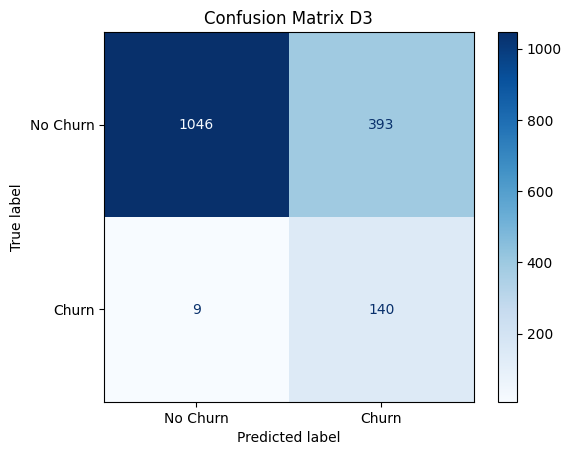

In [83]:
# Display confusion matrix
conf_matrix_D3 = confusion_matrix(y_test, y_pred_D3)
disp_D3 = ConfusionMatrixDisplay(conf_matrix_D3, display_labels=['No Churn','Churn'])
disp_D3.plot(cmap='Blues')
plt.title('Confusion Matrix D3')
plt.show()

In [84]:
# Values for false positive (fp_D3), false negative (fn_D3), true positive (tp_D3) and true negative (tn_D3)
fp_D3 = conf_matrix_D3[0][1]
fn_D3 = conf_matrix_D3[1][0]
tp_D3 = conf_matrix_D3[1][1]
tn_D3 = conf_matrix_D3[0][0]

print(f' fp_D3: {fp_D3} \n fn_D3: {fn_D3} \n tp_D3: {tp_D3} \n tn_D3: {tn_D3}')

 fp_D3: 393 
 fn_D3: 9 
 tp_D3: 140 
 tn_D3: 1046


In [85]:
# Calculations for accuracy, precision, recall
accuracy_D3 = (tp_D3 + tn_D3)/len(y_test)
precision_D3 = tp_D3/(tp_D3 + fp_D3)
recall_D3 = tp_D3/(tp_D3 + fn_D3)

print(f'Accuracy: {accuracy_D3:.2f}')
print(f'Precision: {precision_D3:.2f}')
print(f'Recall: {recall_D3:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.26
Recall: 0.94
---------------


In [86]:
# Calculate F2 score
beta = 2
F2_score_D3 = (1 + beta**2) * (precision_D3 * recall_D3) / (beta**2 * precision_D3 + recall_D3)

print(f'The F2 score is {F2_score_D3:.4f}')

The F2 score is 0.6200


In [87]:
# Profit/loss analysis
Profit_Loss_D3 = tp_D3*(L - C) - fp_D3*C - fn_D3*L

print(f'The profit or loss is ${Profit_Loss_D3}')

The profit or loss is $44180


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

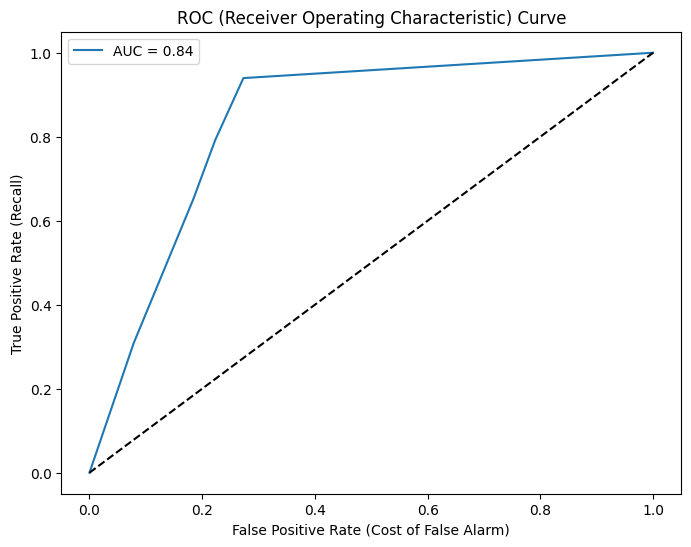

In [88]:
# Plot the ROC Curve
y_probs_D3 = grid_dtree_D3_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_D3)
auc_D3 = round(roc_auc_score(y_test, y_probs_D3), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_D3):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [89]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_D3 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_D3 :.4f}')

The optimal threshold is 0.6738


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [90]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_D3)
avg_precision = average_precision_score(y_test, y_probs_D3)

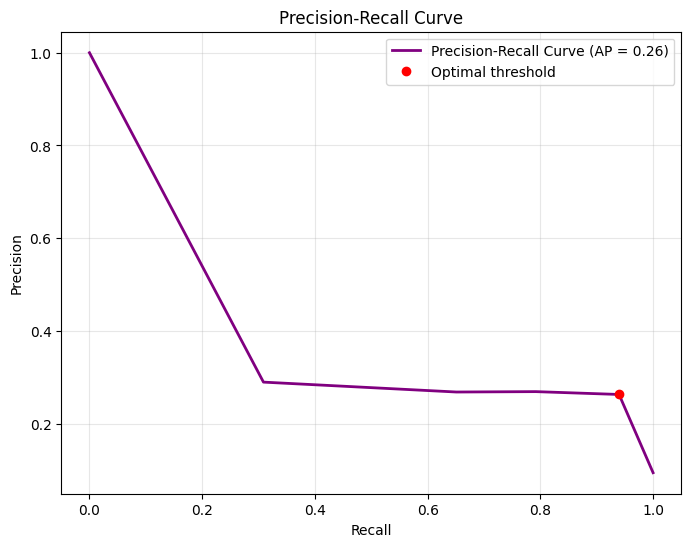

In [91]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_D3))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [92]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0.05, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_D3 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.05 | Precision=0.09 | Recall=1.00
Threshold=0.10 | Precision=0.09 | Recall=1.00
Threshold=0.15 | Precision=0.09 | Recall=1.00
Threshold=0.20 | Precision=0.26 | Recall=0.94
Threshold=0.25 | Precision=0.26 | Recall=0.94
Threshold=0.30 | Precision=0.26 | Recall=0.94
Threshold=0.35 | Precision=0.26 | Recall=0.94
Threshold=0.40 | Precision=0.26 | Recall=0.94
Threshold=0.45 | Precision=0.26 | Recall=0.94
Threshold=0.50 | Precision=0.26 | Recall=0.94
Threshold=0.55 | Precision=0.26 | Recall=0.94
Threshold=0.60 | Precision=0.26 | Recall=0.94
Threshold=0.65 | Precision=0.26 | Recall=0.94
Threshold=0.70 | Precision=0.27 | Recall=0.79
Threshold=0.75 | Precision=0.29 | Recall=0.31


In [93]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_D3 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.2


In [94]:
# Define Model D3 threshold
threshold_D3 = best_threshold

In [95]:
# Use the threshold that maximizes profit
y_pred_D3 = (y_probs_D3 >= best_threshold).astype(int)

In [96]:
# Generate classification report

print(classification_report(y_test, y_pred_D3))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      1439
           1       0.26      0.94      0.41       149

    accuracy                           0.75      1588
   macro avg       0.63      0.83      0.62      1588
weighted avg       0.92      0.75      0.80      1588



As shown in the classification report, the **metrics are the same**.


**Feature Importance Model D3**     
The model finds the following features to be important: **csat_score**	, **tenure_months**	, **monthly_logins**	, and **payment_failures**.

In [97]:
# Retrieve selected features
mask = grid_dtree_D3_opt.named_steps["feature_selection"].get_support()
feature_names = grid_dtree_D3_opt.named_steps["preprocessor"].get_feature_names_out()
selected_features = feature_names[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names

print(f'There are {len(selected_features)} selected features.')

There are 23 selected features.


In [98]:
# Match importance to feature names
tree_model = grid_dtree_D3_opt.named_steps["dtree"]
importances = tree_model.feature_importances_

D3_feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Reset index
D3_feature_importance_df = D3_feature_importance_df.reset_index(drop=True)
D3_feature_importance_df.index = D3_feature_importance_df.index + 1
D3_feature_importance_df.index.name = "Rank"

D3_feature_importance_df.head(10)

,feature,importance
Rank,,
1,csat_score,0.329093
2,tenure_months,0.283377
3,payment_failures,0.201975
4,monthly_logins,0.185555
5,survey_response,0.000000
6,gender_Female,0.000000
7,gender_Male,0.000000
8,customer_segment_SME,0.000000
9,city_New York,0.000000


In [99]:
# Select the first twenty features
D3_feature_importance_df = D3_feature_importance_df.iloc[:20]

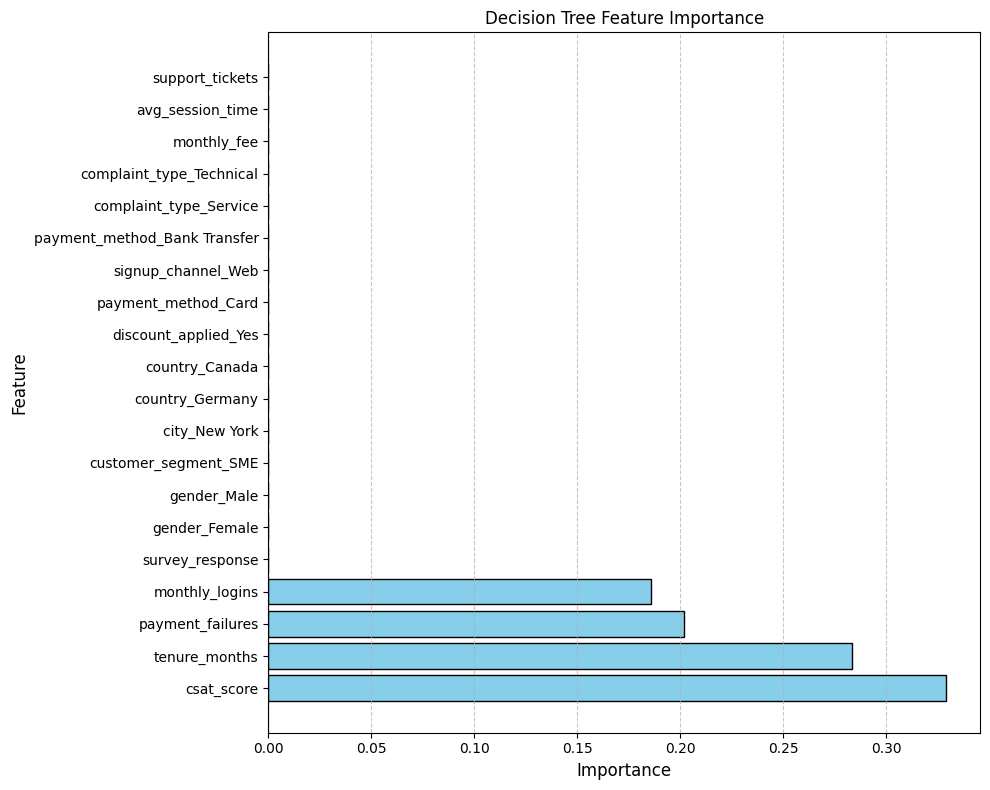

In [100]:
# Plot the feature and importance
plt.figure(figsize=(10, 8))
colors = ['skyblue']
plt.barh(D3_feature_importance_df['feature'], D3_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different Decision Tree models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [101]:
# Build a dataframe summarizing the model properties
dtree_models_df = pd.DataFrame({
    'Model': ['Model D1','Model D2','Model D3'],
    'AUC': [auc_D1, auc_D2, auc_D3],
    'Accuracy': [accuracy_D1, accuracy_D2, accuracy_D3],
    'Precision': [precision_D1, precision_D2, precision_D3],
    'Recall': [recall_D1, recall_D2, recall_D3],
    'F2 Score': [F2_score_D1, F2_score_D2, F2_score_D3],
    'Profit/Loss': [Profit_Loss_D1, Profit_Loss_D2, Profit_Loss_D3],
})
dtree_models_df

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model D1,0.823,0.748111,0.260952,0.919463,0.611062,41500
1,Model D2,0.823,0.748111,0.260952,0.919463,0.611062,41500
2,Model D3,0.839,0.746851,0.262664,0.939597,0.620018,44180


In [102]:
# Provide an interactive Plotly plot
fig = go.Figure()

# Primary y-axis
metrics = ['AUC','Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=dtree_models_df['Model'],
          y=dtree_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=dtree_models_df['Model'],
          y=dtree_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='Model'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [103]:
# Output the best Decision Tree model performance metrics based on profit/loss
dtree_metrics_df = dtree_models_df.loc[[dtree_models_df["Profit/Loss"].idxmax()]]

dtree_metrics_df.to_csv("dtree_metrics.csv", index=False)

dtree_metrics_df.head()

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
2,Model D3,0.839,0.746851,0.262664,0.939597,0.620018,44180


In [104]:
# Output the first eight (8) features importance
model = dtree_metrics_df.iloc[0, 0]

if model == 'Model D1':
  print(D1_feature_importance_df.head(8), '\n')
  D1_feature_importance_df.to_csv("dtree_features.csv", index=False)
elif model == 'Model D2':
  print(D2_feature_importance_df.head(8), '\n')
  D2_feature_importance_df.to_csv("dtree_features.csv", index=False)
else:
  print(D3_feature_importance_df.head(8), '\n')
  D3_feature_importance_df.to_csv("dtree_features.csv", index=False)

print(f'The best model is {model}.')

                   feature  importance
Rank                                  
1               csat_score    0.329093
2            tenure_months    0.283377
3         payment_failures    0.201975
4           monthly_logins    0.185555
5          survey_response    0.000000
6            gender_Female    0.000000
7              gender_Male    0.000000
8     customer_segment_SME    0.000000 

The best model is Model D3.


**Sample Predictions**  

In [105]:
# Establish best model
model = dtree_metrics_df.iloc[0, 0]

if model == 'Model D1':
  model_opt = dtree_pipe1_opt
  best_threshold = threshold_D1
elif model == 'Model D2':
  model_opt = grid_dtree_D2_opt
  best_threshold = threshold_D2
else:
  model_opt = grid_dtree_D3_opt
  best_threshold = threshold_D3

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model D3 and the best threshold is 0.2.


**Sample 1**     


In [106]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [107]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [108]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = model_opt.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.67


**Sample 2**     


In [109]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [110]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [111]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = model_opt.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.17


**Sample 3**    


In [112]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [113]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [114]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = model_opt.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.17


**Sample 4**     


In [115]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [116]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [117]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = model_opt.predict_proba(pd.DataFrame([sample4]))[:, 1][0]

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.72


**Sample 5**    


In [118]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [119]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [120]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = model_opt.predict_proba(pd.DataFrame([sample5]))[:, 1][0]

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5:.2f}')

The predicted churn is 0 

The predicted churn probability is 0.17
